# 08 - Reid Stiffness-to-P-Ratio Affine Rollout Test

Small sanity test on the Reid dataset.

Known empirical fact: initial `stiffness_std` correlates strongly with final p-ratio. This notebook asks whether that static signal is already enough to predict final p-ratio, then turns the predicted p-ratio into a simple 100-transition affine rollout.

The rollout is intentionally simple: use the dataset's average x-compression schedule, then choose y-motion from the predicted p-ratio. No neural simulator is trained here.

In [51]:
# Imports.

import json
import os
import random
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data

from graph_utils import calc_p_ratio_rollout_sides, directional_side_indices_from_box
from lss.graph import clone_graph
from lss.plotting import PAPER_COLORS, apply_editorial_style, style_axes

apply_editorial_style()

try:
    display
except NameError:
    def display(*args, **kwargs):
        return None



In [52]:
# Config.

seed = 6574
random.seed(seed)
rng = np.random.default_rng(seed)

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent

cfg = {
    'dataset_path': str(ROOT / 'data' / 'new_reid_combined.pt'),
    'train_count': 15,
    'train_min_p_ratio': 0.1,
    'rollout_steps': 100,
    'take_every_kth_frame': 1,
    'side_quantile': 0.10,
    'selected_static_features': ['stiffness_std', 'soft_frac_lt_0p1'],
    'selected_static_ridge_alpha': 1.0,
    'output_dir': str(ROOT / 'notebooks' / 'results' / 'reid_stiffness_pratio_affine_rollout'),
}
output_dir = Path(cfg['output_dir'])
output_dir.mkdir(parents=True, exist_ok=True)
(output_dir / 'config.json').write_text(json.dumps(cfg, indent=2))
print(json.dumps(cfg, indent=2))


{
  "dataset_path": "/home/alexz/Documents/course_project/data/new_reid_combined.pt",
  "train_count": 15,
  "train_min_p_ratio": 0.1,
  "rollout_steps": 100,
  "take_every_kth_frame": 1,
  "side_quantile": 0.1,
  "selected_static_features": [
    "stiffness_std",
    "soft_frac_lt_0p1"
  ],
  "selected_static_ridge_alpha": 1.0,
  "output_dir": "/home/alexz/Documents/course_project/notebooks/results/reid_stiffness_pratio_affine_rollout"
}


In [53]:
# Load Reid trajectories.

data = torch.load(cfg['dataset_path'], map_location='cpu', weights_only=False)
print('trajectories:', len(data))
print('frames per first trajectory:', len(data[0]))
print('nodes:', data[0][0].x.shape[0], 'edges:', data[0][0].edge_index.shape[1])
print('edge_attr columns look like dx, dy, length, stiffness; using last column as stiffness.')


trajectories: 102
frames per first trajectory: 1500
nodes: 100 edges: 284
edge_attr columns look like dx, dy, length, stiffness; using last column as stiffness.


In [54]:
# Helpers.

def side_width_height(graph, side_idx):
    x = graph.x.detach().cpu().numpy()
    width = float(x[side_idx['right'], 0].mean() - x[side_idx['left'], 0].mean())
    height = float(x[side_idx['top'], 1].mean() - x[side_idx['bottom'], 1].mean())
    return width, height


def unique_initial_stiffness(sim):
    g = sim[0]
    edge_index = g.edge_index.detach().cpu().numpy()
    edge_attr = g.edge_attr.detach().cpu().numpy()
    pair_to_stiffness = {}
    for e in range(edge_index.shape[1]):
        i, j = int(edge_index[0, e]), int(edge_index[1, e])
        key = tuple(sorted((i, j)))
        if key not in pair_to_stiffness:
            pair_to_stiffness[key] = float(edge_attr[e, -1])
    return np.asarray(list(pair_to_stiffness.values()), dtype=float)




def unique_initial_stiffness_by_orientation(sim):
    g = sim[0]
    edge_index = g.edge_index.detach().cpu().numpy()
    edge_attr = g.edge_attr.detach().cpu().numpy()
    xy = g.x[:, :2].detach().cpu().numpy()
    unique = {}
    for e in range(edge_index.shape[1]):
        i, j = int(edge_index[0, e]), int(edge_index[1, e])
        key = tuple(sorted((i, j)))
        if key in unique:
            continue
        vec = xy[j] - xy[i]
        angle = abs(np.arctan2(vec[1], vec[0]))
        angle = min(angle, np.pi - angle)
        stiffness = float(edge_attr[e, -1])
        unique[key] = (angle, stiffness)
    horizontal, vertical, diagonal = [], [], []
    for angle, stiffness in unique.values():
        if angle < np.deg2rad(25):
            horizontal.append(stiffness)
        elif angle > np.deg2rad(65):
            vertical.append(stiffness)
        else:
            diagonal.append(stiffness)
    return {
        'horizontal': np.asarray(horizontal, dtype=float),
        'vertical': np.asarray(vertical, dtype=float),
        'diagonal': np.asarray(diagonal, dtype=float),
    }


def safe_nanstd(values):
    values = np.asarray(values, dtype=float)
    return float(np.nanstd(values)) if values.size else np.nan

def safe_nanmean(values):
    values = np.asarray(values, dtype=float)
    return float(np.nanmean(values)) if values.size else np.nan

def sampled_frame_indices(sim):
    idx = np.arange(0, len(sim), int(cfg['take_every_kth_frame']), dtype=int)
    if len(idx) == 0 or idx[0] != 0:
        idx = np.insert(idx, 0, 0)
    max_frames = int(cfg['rollout_steps']) + 1
    return idx[:max_frames]

def trajectory_geometry(sim, frame_indices, side_idx):
    rows = []
    w0, h0 = side_width_height(sim[0], side_idx)
    for order, frame_idx in enumerate(frame_indices):
        w, h = side_width_height(sim[int(frame_idx)], side_idx)
        rows.append({
            'frame_order': order,
            'frame_idx': int(frame_idx),
            'x_scale': w / w0,
            'y_scale': h / h0,
            'dx': w - w0,
            'dy': h - h0,
        })
    return pd.DataFrame(rows)


def pearson_r(x, y):
    clean = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(clean) < 3 or clean['x'].std() < 1e-12 or clean['y'].std() < 1e-12:
        return np.nan
    return float(clean['x'].corr(clean['y']))


def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 2:
        return np.nan
    denom = float(np.sum((y_true - y_true.mean()) ** 2))
    if denom <= 1e-12:
        return np.nan
    return float(1.0 - np.sum((y_true - y_pred) ** 2) / denom)


def metrics(df, pred_col):
    clean = df[['final_p_ratio', pred_col]].dropna()
    return {
        'n': int(len(clean)),
        'pearson': pearson_r(clean['final_p_ratio'], clean[pred_col]),
        'corr_r2': pearson_r(clean['final_p_ratio'], clean[pred_col]) ** 2,
        'fit_r2': r2_score(clean['final_p_ratio'], clean[pred_col]),
        'mse': float(np.mean((clean['final_p_ratio'] - clean[pred_col]) ** 2)) if len(clean) else np.nan,
        'mae': float(np.mean(np.abs(clean['final_p_ratio'] - clean[pred_col]))) if len(clean) else np.nan,
    }


def fit_linear_static_model(train_df, all_df, feature_cols, target_col='final_p_ratio', ridge_alpha=0.0):
    train_clean = train_df.dropna(subset=feature_cols + [target_col]).copy()
    all_clean = all_df.copy()
    x_train = train_clean[feature_cols].to_numpy(dtype=float)
    y_train = train_clean[target_col].to_numpy(dtype=float)
    x_all = all_clean[feature_cols].to_numpy(dtype=float)
    mu = x_train.mean(axis=0)
    sigma = x_train.std(axis=0)
    sigma[sigma < 1e-12] = 1.0
    x_train_z = (x_train - mu) / sigma
    x_all_z = (x_all - mu) / sigma
    design_train = np.column_stack([np.ones(len(x_train_z)), x_train_z])
    design_all = np.column_stack([np.ones(len(x_all_z)), x_all_z])
    if ridge_alpha and ridge_alpha > 0:
        penalty = np.diag([0.0] + [1.0] * (design_train.shape[1] - 1))
        beta = np.linalg.solve(design_train.T @ design_train + ridge_alpha * penalty, design_train.T @ y_train)
    else:
        beta = np.linalg.lstsq(design_train, y_train, rcond=None)[0]
    pred = design_all @ beta
    return pred, {'features': feature_cols, 'mu': mu, 'sigma': sigma, 'beta': beta}


In [55]:
# Build static descriptor table and the common x-compression schedule.

summary_rows = []
all_schedule_rows = []
for sim_idx, sim in enumerate(data):
    side_idx = directional_side_indices_from_box(sim[0], quantile=cfg['side_quantile'])
    stiffness = unique_initial_stiffness(sim)
    oriented_stiffness = unique_initial_stiffness_by_orientation(sim)
    frame_indices = sampled_frame_indices(sim)
    target_index = int(frame_indices[-1])
    final_p_ratio = float(calc_p_ratio_rollout_sides(sim, target_index, side_idx=side_idx))
    w0, h0 = side_width_height(sim[0], side_idx)
    wf, hf = side_width_height(sim[-1], side_idx)
    geom = trajectory_geometry(sim, frame_indices, side_idx)
    geom['sim_idx'] = sim_idx
    all_schedule_rows.append(geom)
    summary_rows.append({
        'sim_idx': sim_idx,
        'frames': len(sim),
        'nodes': int(sim[0].x.shape[0]),
        'edges_directed': int(sim[0].edge_index.shape[1]),
        'edges_unique': int(len(stiffness)),
        'stiffness_mean': float(np.nanmean(stiffness)),
        'stiffness_std': float(np.nanstd(stiffness)),
        'stiffness_cv': float(np.nanstd(stiffness) / (np.nanmean(stiffness) + 1e-12)),
        'stiffness_min': float(np.nanmin(stiffness)),
        'stiffness_max': float(np.nanmax(stiffness)),
        'stiffness_q10': float(np.nanquantile(stiffness, 0.10)),
        'stiffness_q20': float(np.nanquantile(stiffness, 0.20)),
        'stiffness_q40': float(np.nanquantile(stiffness, 0.40)),
        'stiffness_q50': float(np.nanquantile(stiffness, 0.50)),
        'stiffness_q75': float(np.nanquantile(stiffness, 0.75)),
        'soft_frac_lt_0p075': float(np.nanmean(stiffness < 0.075)),
        'soft_frac_lt_0p1': float(np.nanmean(stiffness < 0.10)),
        'soft_frac_lt_0p15': float(np.nanmean(stiffness < 0.15)),
        'soft_frac_lt_0p2': float(np.nanmean(stiffness < 0.20)),
        'h_stiffness_mean': safe_nanmean(oriented_stiffness['horizontal']),
        'h_stiffness_std': safe_nanstd(oriented_stiffness['horizontal']),
        'v_stiffness_mean': safe_nanmean(oriented_stiffness['vertical']),
        'v_stiffness_std': safe_nanstd(oriented_stiffness['vertical']),
        'd_stiffness_mean': safe_nanmean(oriented_stiffness['diagonal']),
        'd_stiffness_std': safe_nanstd(oriented_stiffness['diagonal']),
        'final_p_ratio': final_p_ratio,
        'target_frame_idx': target_index,
        'sampled_frames': int(len(frame_indices)),
        'initial_width': w0,
        'initial_height': h0,
        'final_width': wf,
        'final_height': hf,
        'final_x_scale': wf / w0,
        'final_y_scale': hf / h0,
        'final_dx': wf - w0,
        'final_dy': hf - h0,
    })

summary_df = pd.DataFrame(summary_rows)
schedule_df = pd.concat(all_schedule_rows, ignore_index=True)
summary_df.to_csv(output_dir / 'reid_static_descriptors.csv', index=False)
schedule_df.to_csv(output_dir / 'reid_x_y_scale_schedule.csv', index=False)

print('stiffness_std -> final_p_ratio Pearson:', pearson_r(summary_df['stiffness_std'], summary_df['final_p_ratio']))
print('soft_frac_lt_0p075 -> final_p_ratio Pearson:', pearson_r(summary_df['soft_frac_lt_0p075'], summary_df['final_p_ratio']))
print('stiffness_cv -> final_p_ratio Pearson:', pearson_r(summary_df['stiffness_cv'], summary_df['final_p_ratio']))
print('d_stiffness_std -> final_p_ratio Pearson:', pearson_r(summary_df['d_stiffness_std'], summary_df['final_p_ratio']))
display(summary_df.head().round(4))


stiffness_std -> final_p_ratio Pearson: -0.9701817454554774
soft_frac_lt_0p075 -> final_p_ratio Pearson: -0.9538337432321458
stiffness_cv -> final_p_ratio Pearson: -0.950460575320551
d_stiffness_std -> final_p_ratio Pearson: -0.9705097480815927


,sim_idx,frames,nodes,edges_directed,edges_unique,stiffness_mean,stiffness_std,stiffness_cv,stiffness_min,stiffness_max,...,target_frame_idx,sampled_frames,initial_width,initial_height,final_width,final_height,final_x_scale,final_y_scale,final_dx,final_dy
0,0,1500,100,284,284,0.6060,0.3250,0.5362,0.0095,1.3374,...,100,101,9.8479,10.0060,9.5434,9.9815,0.9691,0.9976,-0.3045,-0.0245
1,1,1500,128,364,364,0.4328,0.0608,0.1404,0.3299,0.6249,...,100,101,11.2538,11.1156,10.9168,11.2293,0.9701,1.0102,-0.3370,0.1137
2,2,1500,100,291,291,0.4985,0.1740,0.3490,0.1794,1.0433,...,100,101,9.9042,10.0132,9.6073,10.0797,0.9700,1.0066,-0.2969,0.0665
3,3,1500,108,310,310,0.6419,0.3912,0.6095,0.0006,1.2166,...,100,101,10.1916,10.2174,9.8539,10.1662,0.9669,0.9950,-0.3377,-0.0512
4,4,1500,108,311,311,0.6424,0.3865,0.6017,0.0005,1.2446,...,100,101,10.1321,10.1879,9.8004,10.1042,0.9673,0.9918,-0.3317,-0.0837


In [56]:
# Train/test split and fit p-ratio from stiffness descriptors.

eligible_train = summary_df[summary_df['final_p_ratio'].gt(cfg['train_min_p_ratio'])]['sim_idx'].to_numpy(dtype=int).copy()
rng.shuffle(eligible_train)
if len(eligible_train) < cfg['train_count']:
    raise ValueError(f"Only {len(eligible_train)} networks have final_p_ratio > {cfg['train_min_p_ratio']}; requested train_count={cfg['train_count']}.")
train_idx = set(eligible_train[:cfg['train_count']].tolist())
summary_df['split'] = np.where(summary_df['sim_idx'].isin(train_idx), 'train', 'test')

train_df = summary_df[summary_df['split'].eq('train')].copy()
test_df = summary_df[summary_df['split'].eq('test')].copy()
print('eligible train networks above p-ratio threshold:', len(eligible_train))
print('train final p-ratio range:', float(train_df['final_p_ratio'].min()), float(train_df['final_p_ratio'].max()))
print('test final p-ratio range:', float(test_df['final_p_ratio'].min()), float(test_df['final_p_ratio'].max()))

coef = np.polyfit(train_df['stiffness_std'].to_numpy(float), train_df['final_p_ratio'].to_numpy(float), deg=1)
slope, intercept = float(coef[0]), float(coef[1])
summary_df['pred_p_ratio_stiffness_std'] = slope * summary_df['stiffness_std'] + intercept

selected_features = list(cfg['selected_static_features'])
selected_pred, selected_model = fit_linear_static_model(train_df, summary_df, selected_features, ridge_alpha=cfg['selected_static_ridge_alpha'])
summary_df['pred_p_ratio_selected_static'] = selected_pred

metric_rows = []
for split_name, split_df in summary_df.groupby('split', sort=False):
    for pred_col, label in [
        ('pred_p_ratio_stiffness_std', 'linear stiffness_std -> p_ratio'),
        ('pred_p_ratio_selected_static', 'linear selected stiffness descriptors -> p_ratio'),
    ]:
        row = {'split': split_name, 'prediction': label, 'pred_col': pred_col}
        row.update(metrics(split_df, pred_col))
        metric_rows.append(row)
metric_df = pd.DataFrame(metric_rows)
metric_df.to_csv(output_dir / 'static_pratio_prediction_metrics.csv', index=False)
summary_df.to_csv(output_dir / 'static_pratio_predictions.csv', index=False)

print(f'single fit on train: p_ratio = {slope:.4f} * stiffness_std + {intercept:.4f}')
print('selected stiffness features:', selected_features)
print('selected ridge alpha:', cfg['selected_static_ridge_alpha'])
print('selected standardized coefficients:', dict(zip(['intercept'] + selected_features, selected_model['beta'])))
display(metric_df[['split', 'prediction', 'n', 'fit_r2', 'mse', 'mae']].rename(columns={'fit_r2': 'R2'}).round(4))


eligible train networks above p-ratio threshold: 37
train final p-ratio range: 0.11177906809741685 0.32336824288585636
test final p-ratio range: -0.2976615429445618 0.38553002821442967
single fit on train: p_ratio = -0.9636 * stiffness_std + 0.3785
selected stiffness features: ['stiffness_std', 'soft_frac_lt_0p1']
selected ridge alpha: 1.0
selected standardized coefficients: {'intercept': np.float64(0.20896417220758956), 'stiffness_std': np.float64(-0.04207221060623797), 'soft_frac_lt_0p1': np.float64(-0.014661652692184187)}


,split,prediction,n,R2,mse,mae
0,test,linear stiffness_std -> p_ratio,87,0.4734,0.0168,0.1069
1,test,linear selected stiffness descriptors -> p_ratio,87,0.9313,0.0022,0.0374
2,train,linear stiffness_std -> p_ratio,15,0.9187,0.0003,0.0138
3,train,linear selected stiffness descriptors -> p_ratio,15,0.9430,0.0002,0.0101


In [57]:
# Build the every-kth-frame affine rollout from predicted p-ratio.
# Use the train-set mean x-scale schedule. y-scale is solved from dy = -p_pred * dx.

train_schedule = schedule_df[schedule_df['sim_idx'].isin(train_idx)].copy()
x_schedule = (
    train_schedule.groupby('frame_order', as_index=False)['x_scale']
    .mean()
    .sort_values('frame_order')['x_scale']
    .to_numpy(dtype=float)
)
print('x-scale schedule length:', len(x_schedule), 'rollout transitions:', len(x_schedule) - 1, 'take every kth frame:', cfg['take_every_kth_frame'], 'final mean x-scale:', x_schedule[-1])


def affine_pratio_rollout(sim, pred_p_ratio, x_scale_schedule):
    first = sim[0]
    side_idx = directional_side_indices_from_box(first, quantile=cfg['side_quantile'])
    w0, h0 = side_width_height(first, side_idx)
    x0 = first.x.detach().cpu().clone()
    center = x0.mean(dim=0, keepdim=True)
    rollout = []
    for x_scale in x_scale_schedule:
        dx = w0 * (float(x_scale) - 1.0)
        dy = -float(pred_p_ratio) * dx
        y_scale = (h0 + dy) / h0
        g = clone_graph(first).cpu()
        xy = x0.clone()
        xy[:, 0] = center[0, 0] + (x0[:, 0] - center[0, 0]) * float(x_scale)
        xy[:, 1] = center[0, 1] + (x0[:, 1] - center[0, 1]) * float(y_scale)
        g.x[:, :2] = xy[:, :2]
        rollout.append(g)
    return rollout

rollout_rows = []
for _, row in summary_df.iterrows():
    sim_idx = int(row['sim_idx'])
    sim = data[sim_idx]
    pred_p = float(row['pred_p_ratio_selected_static'])
    pred_rollout = affine_pratio_rollout(sim, pred_p, x_schedule)
    pred_rollout_p = float(calc_p_ratio_rollout_sides(pred_rollout, -1))
    rollout_rows.append({
        'sim_idx': sim_idx,
        'split': row['split'],
        'true_p_ratio': float(row['final_p_ratio']),
        'pred_p_ratio_stiffness_std': float(row['pred_p_ratio_stiffness_std']),
        'pred_p_ratio_selected_static': pred_p,
        'pred_p_ratio_rollout': pred_rollout_p,
        'stiffness_std': float(row['stiffness_std']),
        'soft_frac_lt_0p1': float(row['soft_frac_lt_0p1']),
    })

rollout_df = pd.DataFrame(rollout_rows)
rollout_metric_rows = []
for split_name, split_df in rollout_df.groupby('split', sort=False):
    tmp = split_df.rename(columns={'true_p_ratio': 'final_p_ratio'})
    for pred_col in ['pred_p_ratio_stiffness_std', 'pred_p_ratio_selected_static', 'pred_p_ratio_rollout']:
        row = {'split': split_name, 'prediction': pred_col}
        row.update(metrics(tmp, pred_col))
        rollout_metric_rows.append(row)
rollout_metric_df = pd.DataFrame(rollout_metric_rows)
rollout_df.to_csv(output_dir / 'affine_rollout_pratio_predictions.csv', index=False)
rollout_metric_df.to_csv(output_dir / 'affine_rollout_pratio_metrics.csv', index=False)

display(rollout_metric_df[['split', 'prediction', 'n', 'fit_r2', 'mse', 'mae']].rename(columns={'fit_r2': 'R2'}).round(4))


x-scale schedule length: 101 rollout transitions: 100 take every kth frame: 1 final mean x-scale: 0.9980118051142404


,split,prediction,n,R2,mse,mae
0,test,pred_p_ratio_stiffness_std,87,0.4734,0.0168,0.1069
1,test,pred_p_ratio_selected_static,87,0.9313,0.0022,0.0374
2,test,pred_p_ratio_rollout,87,0.9313,0.0022,0.0374
3,train,pred_p_ratio_stiffness_std,15,0.9187,0.0003,0.0138
4,train,pred_p_ratio_selected_static,15,0.9430,0.0002,0.0101
5,train,pred_p_ratio_rollout,15,0.9429,0.0002,0.0101


In [58]:
# Node-position MSE against ground-truth sampled frames.
# This checks whether matching final p-ratio also means matching the actual node motion.

mse_rows = []
for _, row in summary_df.iterrows():
    sim_idx = int(row['sim_idx'])
    sim = data[sim_idx]
    pred_rollout = affine_pratio_rollout(sim, float(row['pred_p_ratio_selected_static']), x_schedule)
    frame_indices = sampled_frame_indices(sim)[:len(x_schedule)]
    for step, frame_idx in enumerate(frame_indices):
        true_xy = sim[int(frame_idx)].x[:, :2].detach().cpu().numpy()
        pred_xy = pred_rollout[step].x[:, :2].detach().cpu().numpy()
        per_node_sq = np.sum((pred_xy - true_xy) ** 2, axis=1)
        mse_rows.append({
            'sim_idx': sim_idx,
            'split': row['split'],
            'step': int(step),
            'frame_idx': int(frame_idx),
            'node_pos_mse': float(np.mean(per_node_sq)),
            'node_pos_rmse': float(np.sqrt(np.mean(per_node_sq))),
            'node_pos_mae': float(np.mean(np.linalg.norm(pred_xy - true_xy, axis=1))),
        })

node_mse_df = pd.DataFrame(mse_rows)
node_mse_summary_df = (
    node_mse_df
    .groupby(['split', 'step'], as_index=False)
    .agg(
        frame_idx=('frame_idx', 'median'),
        node_pos_mse_mean=('node_pos_mse', 'mean'),
        node_pos_mse_std=('node_pos_mse', 'std'),
        node_pos_mse_median=('node_pos_mse', 'median'),
        node_pos_rmse_mean=('node_pos_rmse', 'mean'),
        node_pos_mae_mean=('node_pos_mae', 'mean'),
    )
)
final_node_mse_df = node_mse_df[node_mse_df['step'].eq(node_mse_df['step'].max())].copy()
final_node_mse_metrics = (
    final_node_mse_df
    .groupby('split', as_index=False)
    .agg(
        n=('sim_idx', 'count'),
        final_node_pos_mse_mean=('node_pos_mse', 'mean'),
        final_node_pos_mse_median=('node_pos_mse', 'median'),
        final_node_pos_rmse_mean=('node_pos_rmse', 'mean'),
        final_node_pos_mae_mean=('node_pos_mae', 'mean'),
    )
)

node_mse_df.to_csv(output_dir / 'affine_rollout_node_mse_by_step.csv', index=False)
node_mse_summary_df.to_csv(output_dir / 'affine_rollout_node_mse_summary_by_step.csv', index=False)
final_node_mse_metrics.to_csv(output_dir / 'affine_rollout_final_node_mse_metrics.csv', index=False)

display(final_node_mse_metrics.round(5))


,split,n,final_node_pos_mse_mean,final_node_pos_mse_median,final_node_pos_rmse_mean,final_node_pos_mae_mean
0,test,87,0.0,0.00001,0.00208,0.00180
1,train,15,0.0,0.00000,0.00088,0.00073


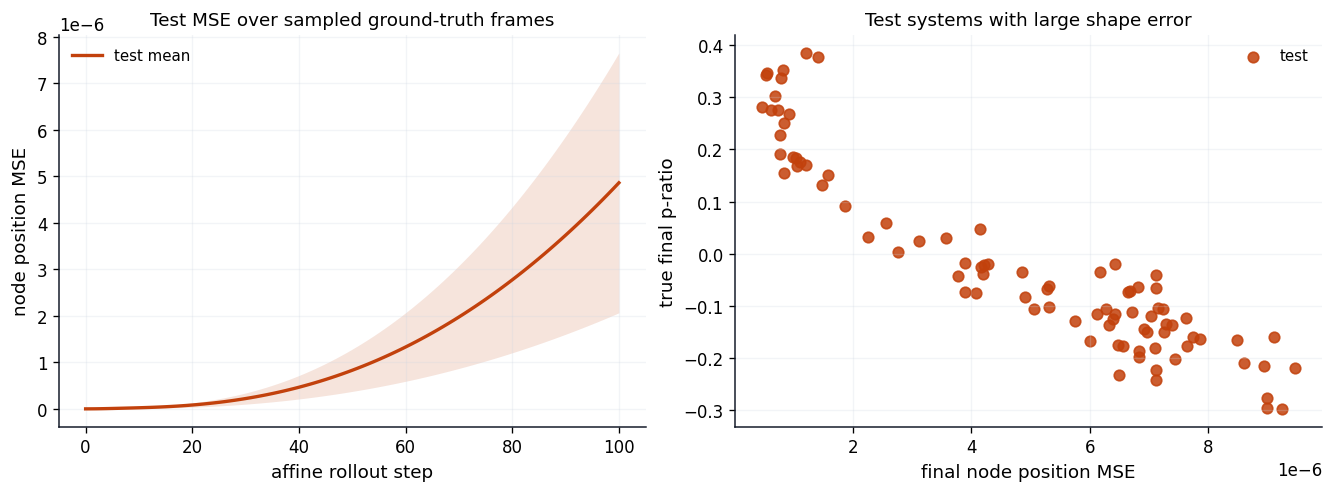

In [59]:
# Plot test node-position MSE over affine rollout steps.

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

test_mse_summary = node_mse_summary_df[node_mse_summary_df['split'].eq('test')].sort_values('step')
test_final_mse = final_node_mse_df[final_node_mse_df['split'].eq('test')].copy()

ax = axes[0]
color = PAPER_COLORS['orange']
ax.plot(test_mse_summary['step'], test_mse_summary['node_pos_mse_mean'], lw=2.0, color=color, label='test mean')
lo = test_mse_summary['node_pos_mse_mean'] - test_mse_summary['node_pos_mse_std']
hi = test_mse_summary['node_pos_mse_mean'] + test_mse_summary['node_pos_mse_std']
ax.fill_between(test_mse_summary['step'], lo, hi, color=color, alpha=0.14, linewidth=0)
style_axes(ax, xlabel='affine rollout step', ylabel='node position MSE', legend=True)
ax.set_title('Test MSE over sampled ground-truth frames')

ax = axes[1]
ax.scatter(
    test_final_mse['node_pos_mse'],
    rollout_df.set_index('sim_idx').loc[test_final_mse['sim_idx'], 'true_p_ratio'],
    s=40, alpha=0.85, color=color, label='test'
)
style_axes(ax, xlabel='final node position MSE', ylabel='true final p-ratio', legend=True)
ax.set_title('Test systems with large shape error')

fig.savefig(output_dir / 'affine_rollout_node_mse.png', dpi=200, bbox_inches='tight')
plt.show()


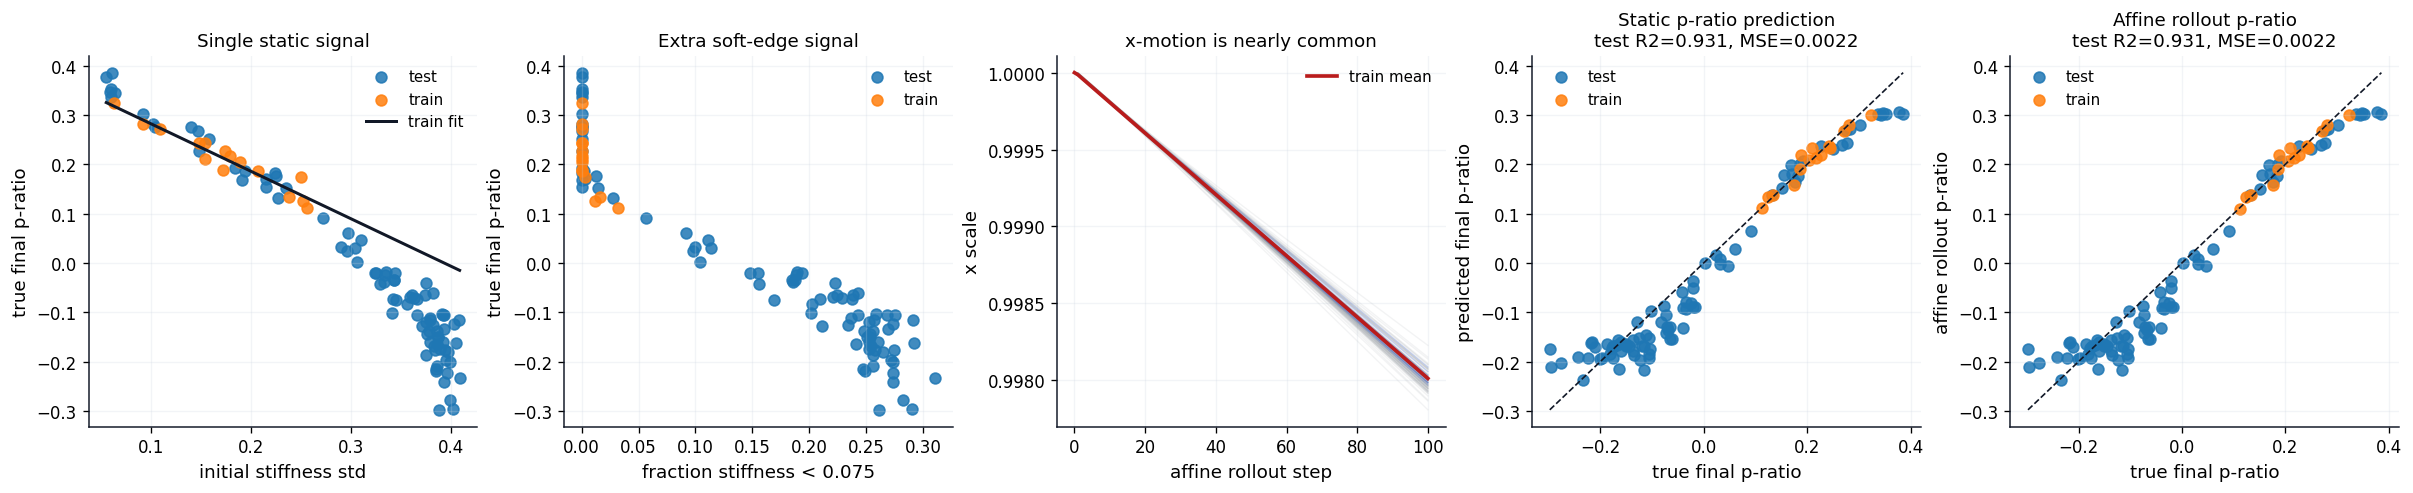

In [60]:
# Plots: descriptor relation, x schedule, and final p-ratio prediction.

fig, axes = plt.subplots(1, 5, figsize=(20, 4), constrained_layout=True)

ax = axes[0]
for split_name, group in summary_df.groupby('split', sort=False):
    ax.scatter(group['stiffness_std'], group['final_p_ratio'], s=42, alpha=0.85, label=split_name)
xx = np.linspace(summary_df['stiffness_std'].min(), summary_df['stiffness_std'].max(), 100)
ax.plot(xx, slope * xx + intercept, color=PAPER_COLORS['ink'], lw=1.8, label='train fit')
style_axes(ax, xlabel='initial stiffness std', ylabel='true final p-ratio', legend=True)
ax.set_title('Single static signal')

ax = axes[1]
for split_name, group in summary_df.groupby('split', sort=False):
    ax.scatter(group['soft_frac_lt_0p075'], group['final_p_ratio'], s=42, alpha=0.85, label=split_name)
style_axes(ax, xlabel='fraction stiffness < 0.075', ylabel='true final p-ratio', legend=True)
ax.set_title('Extra soft-edge signal')

ax = axes[2]
for sim_idx, group in schedule_df.groupby('sim_idx'):
    alpha = 0.12 if sim_idx not in train_idx else 0.22
    color = '#9AA0A6' if sim_idx not in train_idx else PAPER_COLORS['blue']
    ax.plot(group['frame_order'], group['x_scale'], color=color, alpha=alpha, lw=0.8)
ax.plot(np.arange(len(x_schedule)), x_schedule, color=PAPER_COLORS['red'], lw=2.2, label='train mean')
style_axes(ax, xlabel='affine rollout step', ylabel='x scale', legend=True)
ax.set_title('x-motion is nearly common')

test_pred_metric = metric_df[metric_df['split'].eq('test') & metric_df['pred_col'].eq('pred_p_ratio_selected_static')].iloc[0]
test_rollout_metric = rollout_metric_df[rollout_metric_df['split'].eq('test') & rollout_metric_df['prediction'].eq('pred_p_ratio_rollout')].iloc[0]

ax = axes[3]
for split_name, group in summary_df.groupby('split', sort=False):
    ax.scatter(group['final_p_ratio'], group['pred_p_ratio_selected_static'], s=42, alpha=0.85, label=split_name)
lo = np.nanmin([summary_df['final_p_ratio'].min(), summary_df['pred_p_ratio_selected_static'].min()])
hi = np.nanmax([summary_df['final_p_ratio'].max(), summary_df['pred_p_ratio_selected_static'].max()])
ax.plot([lo, hi], [lo, hi], color=PAPER_COLORS['ink'], lw=1.0, ls='--')
style_axes(ax, xlabel='true final p-ratio', ylabel='predicted final p-ratio', legend=True)
ax.set_title(f"Static p-ratio prediction\ntest R2={test_pred_metric['fit_r2']:.3f}, MSE={test_pred_metric['mse']:.4f}")

ax = axes[4]
for split_name, group in rollout_df.groupby('split', sort=False):
    ax.scatter(group['true_p_ratio'], group['pred_p_ratio_rollout'], s=42, alpha=0.85, label=split_name)
lo = np.nanmin([rollout_df['true_p_ratio'].min(), rollout_df['pred_p_ratio_rollout'].min()])
hi = np.nanmax([rollout_df['true_p_ratio'].max(), rollout_df['pred_p_ratio_rollout'].max()])
ax.plot([lo, hi], [lo, hi], color=PAPER_COLORS['ink'], lw=1.0, ls='--')
style_axes(ax, xlabel='true final p-ratio', ylabel='affine rollout p-ratio', legend=True)
ax.set_title(f"Affine rollout p-ratio\ntest R2={test_rollout_metric['fit_r2']:.3f}, MSE={test_rollout_metric['mse']:.4f}")

fig.savefig(output_dir / 'stiffness_pratio_affine_rollout_summary.png', dpi=200, bbox_inches='tight')
plt.show()


50-transition test final-node-MSE summary


,node_pos_mse_50,node_pos_rmse_50,node_pos_mae_50
count,87.000000,87.000000,87.000000
mean,0.000001,0.000862,0.000752
std,0.000000,0.000297,0.000270
min,0.000000,0.000288,0.000234
25%,0.000000,0.000569,0.000469
50%,0.000001,0.000995,0.000873
75%,0.000001,0.001094,0.000967
max,0.000001,0.001213,0.001075


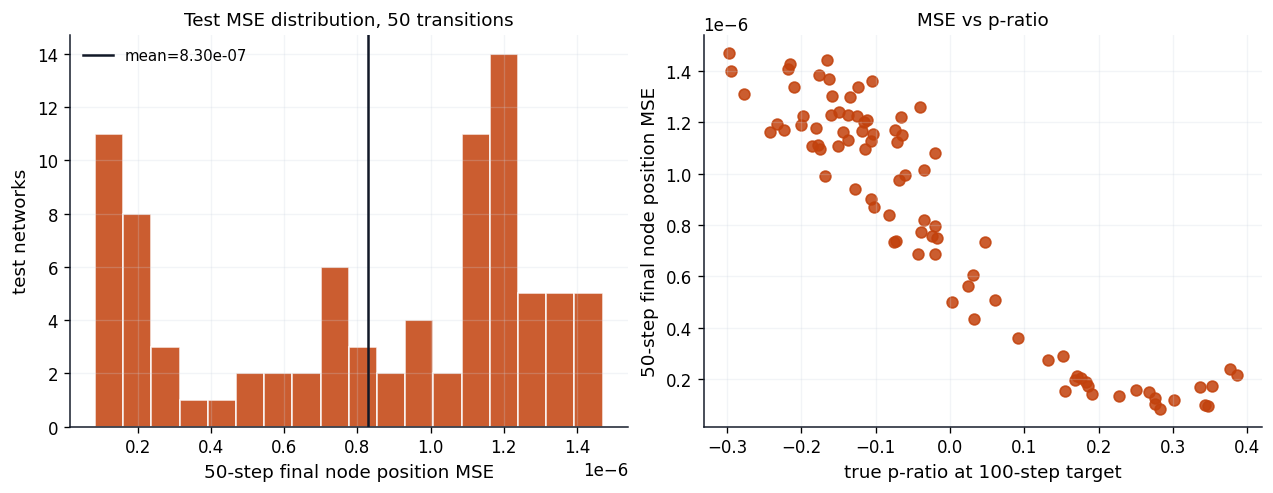

In [61]:
# End diagnostic: test final-node-MSE distribution for a 50-transition rollout.
# Uses the same fitted p-ratio model, but only the first 50 transitions of the train x-scale schedule.

steps_50 = 50
x_schedule_50 = x_schedule[:steps_50 + 1]

mse50_rows = []
for _, row in summary_df[summary_df['split'].eq('test')].iterrows():
    sim_idx = int(row['sim_idx'])
    sim = data[sim_idx]
    pred_rollout = affine_pratio_rollout(sim, float(row['pred_p_ratio_selected_static']), x_schedule_50)
    target_idx = min(steps_50 * int(cfg['take_every_kth_frame']), len(sim) - 1)
    true_xy = sim[target_idx].x[:, :2].detach().cpu().numpy()
    pred_xy = pred_rollout[-1].x[:, :2].detach().cpu().numpy()
    per_node_sq = np.sum((pred_xy - true_xy) ** 2, axis=1)
    mse50_rows.append({
        'sim_idx': sim_idx,
        'target_frame_idx': int(target_idx),
        'true_p_ratio': float(row['final_p_ratio']),
        'pred_p_ratio': float(row['pred_p_ratio_selected_static']),
        'node_pos_mse_50': float(np.mean(per_node_sq)),
        'node_pos_rmse_50': float(np.sqrt(np.mean(per_node_sq))),
        'node_pos_mae_50': float(np.mean(np.linalg.norm(pred_xy - true_xy, axis=1))),
    })

mse50_df = pd.DataFrame(mse50_rows)
mse50_df.to_csv(output_dir / 'affine_rollout_test_50_step_final_node_mse.csv', index=False)

print('50-transition test final-node-MSE summary')
display(mse50_df[['node_pos_mse_50', 'node_pos_rmse_50', 'node_pos_mae_50']].describe().round(6))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), constrained_layout=True)

ax = axes[0]
ax.hist(mse50_df['node_pos_mse_50'], bins=18, color=PAPER_COLORS['orange'], alpha=0.85, edgecolor='white')
ax.axvline(mse50_df['node_pos_mse_50'].mean(), color=PAPER_COLORS['ink'], lw=1.5, label=f"mean={mse50_df['node_pos_mse_50'].mean():.2e}")
style_axes(ax, xlabel='50-step final node position MSE', ylabel='test networks', legend=True)
ax.set_title('Test MSE distribution, 50 transitions')

ax = axes[1]
ax.scatter(mse50_df['true_p_ratio'], mse50_df['node_pos_mse_50'], s=42, alpha=0.85, color=PAPER_COLORS['orange'])
style_axes(ax, xlabel='true p-ratio at 100-step target', ylabel='50-step final node position MSE')
ax.set_title('MSE vs p-ratio')

fig.savefig(output_dir / 'affine_rollout_test_50_step_mse_distribution.png', dpi=200, bbox_inches='tight')
plt.show()


## Selected Static Signal

The selected predictor now uses `stiffness_std` plus one extra stiffness-derived property: `soft_frac_lt_0p1`.

`soft_frac_lt_0p1` is the fraction of unique initial edges whose stiffness is below `0.1`. This keeps the model simple while adding information about the very soft edge population.


## Interpretation

If the `test` split has high p-ratio R2 here, this is a useful baseline: the final p-ratio can be recovered from a static stiffness statistic plus the common x-compression schedule.

That would mean a learned simulator or AE should be judged against this baseline. If it cannot beat this simple descriptor-to-affine-rollout model, it is probably not learning more than the static stiffness proxy.
The node-position MSE plot is a separate diagnostic: the affine model can match p-ratio well while still missing non-affine local motion.

The selected static baseline uses `stiffness_std` plus one extra stiffness-derived property, `soft_frac_lt_0p1`, with ridge alpha `1.0`. The visible tables report only R2/MSE/MAE.
